## Imports and Install Libraries

In [22]:
!pip install -q transformers datasets evaluate seqeval accelerate

In [23]:
import numpy as np
import pandas as pd
import torch
import evaluate

from datasets import load_dataset # Load dataset utilities

# Import Hugging Face tools for tokenization, modeling, batching, training, and evaluation
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer
)

## Load Dataset

In [24]:
# Load the CoNLL-2003 dataset from a parquet-compatible Hugging Face mirror
# This is used because the older script-based loader may not work in newer datasets versions
BERT_Dataset = load_dataset("eriktks/conll2003", revision="refs/convert/parquet")
BERT_Dataset  # Display the dataset splits

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

In [25]:
labels = BERT_Dataset["train"].features["ner_tags"].feature.names
labels
# Extract the NER label names (e.g., O, B-PER, I-PER, etc.)


['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

## Load pretrained BERT model and tokenizer

In [26]:
# Use the cased BERT model because capitalization is important in NER
model_name = "bert-base-cased"

# Use the cased BERT model because capitalization is important in NER
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Mapping between label IDs and label names
id_2_label = {i: label for i, label in enumerate(labels)}
label_2_id = {label: i for i, label in enumerate(labels)}

# Load pretrained BERT with a token classification head for NER
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label=id_2_label,
    label2id=label_2_id
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

## Tokenization and label alignment

In [27]:
def tokenize_and_align_labels(example):
    # Tokenize the input tokens while keeping track of word boundaries
    tokenized_values = tokenizer(
        example["tokens"],
        truncation=True,
        is_split_into_words=True
    )


    labels = []


    # Align word-level labels with tokenized subword pieces
    for i, label in enumerate(example["ner_tags"]):
        word_ids = tokenized_values.word_ids(batch_index=i)
        previous_word_id = None
        label_id = []
        for word_id in word_ids:
            # Ignore special tokens like [CLS] and [SEP]
            if word_id is None:
                label_id.append(-100)

            # Assign label to the first token of each word
            elif word_id != previous_word_id:
                label_id.append(label[word_id])

            # Ignore the remaining subword pieces in loss calculation
            else:
                label_id.append(-100)
            previous_word_id = word_id
        labels.append(label_id)

    # Add aligned labels to the tokenized output
    tokenized_values["labels"] = labels
    return tokenized_values

# Apply tokenization and label alignment to all dataset splits
tokenized_dataset = BERT_Dataset.map(
    tokenize_and_align_labels,
    batched=True)

# Show the processed dataset
tokenized_dataset

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3453
    })
})

## Data Collator

In [28]:
dataCollator = DataCollatorForTokenClassification(tokenizer=tokenizer)
# Dynamically pad sequences in each batch for token classification

## Evaluation Metric

In [29]:
evaluation_metric = evaluate.load("seqeval")
# Load the seqeval metric, which is commonly used for NER evaluation

def compute_metrics(example):
    predictions, labels_ids = example
    predictions = np.argmax(predictions, axis=2)  # Convert logits into predicted label indices

    true_predictions = []
    true_labels = []

    # Remove ignored labels (-100) before computing metrics
    for prediction, label in zip(predictions, labels_ids):
        prediction_tags = []
        label_tags = []

        for p_i, l_i in zip(prediction, label):
            if l_i != -100:
                prediction_tags.append(id_2_label[p_i])
                label_tags.append(id_2_label[l_i])

        true_predictions.append(prediction_tags)
        true_labels.append(label_tags)

    # Compute overall NER metrics
    results = evaluation_metric.compute(predictions=true_predictions, references=true_labels)
    return{
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"]
    }

## Training arguments

In [30]:
training_arguements = TrainingArguments(
    output_dir="BERT_NER",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    push_to_hub=False,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"

)
# Define the training configuration for fine-tuning BERT

## Trainer and Train

In [31]:
trainer = Trainer(
    model=model,
    args=training_arguements,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    data_collator=dataCollator,
    compute_metrics=compute_metrics
) # Create the Trainer object to manage training and evaluation

trainer.train() # Fine-tune the pretrained BERT model on the CoNLL-2003 training set

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.155617,0.096657,0.892066,0.905807,0.898884,0.980683
2,0.028467,0.107655,0.909171,0.914483,0.911819,0.982772
3,0.014723,0.115564,0.908757,0.920503,0.914592,0.983288


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2634, training_loss=0.05068881369578449, metrics={'train_runtime': 627.8962, 'train_samples_per_second': 67.086, 'train_steps_per_second': 4.195, 'total_flos': 1050534559887048.0, 'train_loss': 0.05068881369578449, 'epoch': 3.0})

## Validation

In [32]:
eval_results = trainer.evaluate(tokenized_dataset["validation"])
eval_results
# Evaluate model performance on the validation set

{'eval_loss': 0.03700512275099754,
 'eval_precision': 0.9463300451429527,
 'eval_recall': 0.9525412319084483,
 'eval_f1': 0.9494254801643881,
 'eval_accuracy': 0.9912775982243682,
 'eval_runtime': 9.8003,
 'eval_samples_per_second': 331.623,
 'eval_steps_per_second': 20.816,
 'epoch': 3.0}

## Test

In [33]:
test_results = trainer.evaluate(tokenized_dataset["test"])
test_results
# Evaluate model performance on the validation set

{'eval_loss': 0.11556366831064224,
 'eval_precision': 0.9087572102779234,
 'eval_recall': 0.9205028328611898,
 'eval_f1': 0.9145923124285338,
 'eval_accuracy': 0.9832884677506192,
 'eval_runtime': 9.3558,
 'eval_samples_per_second': 369.077,
 'eval_steps_per_second': 23.087,
 'epoch': 3.0}

## Save the model

In [34]:
trainer.save_model("./bert-ner-model")
tokenizer.save_pretrained("./bert-ner-model")
# Save the fine-tuned BERT model and tokenizer for future use

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bert-ner-model/tokenizer_config.json', './bert-ner-model/tokenizer.json')

## Restults into table for later and save the table

In [35]:
results_df = pd.DataFrame([
    {
        "Dataset": "CoNLL-2003",
        "Model": "bert-base-cased",
        "Learning Rate": "2e-5",
        "Batch Size": 16,
        "Epochs": 3,
        "Validation Precision": eval_results.get("eval_precision"),
        "Validation Recall": eval_results.get("eval_recall"),
        "Validation F1": eval_results.get("eval_f1"),
        "Validation Accuracy": eval_results.get("eval_accuracy"),
        "Test Precision": test_results.get("eval_precision"),
        "Test Recall": test_results.get("eval_recall"),
        "Test F1": test_results.get("eval_f1"),
        "Test Accuracy": test_results.get("eval_accuracy"),
    }
])  # Organize the final evaluation metrics into a table for reporting

results_df  #Display the results table

results_df.to_csv("bert_evaluation_results.csv", index=False)  # Save the results table to a CSV file

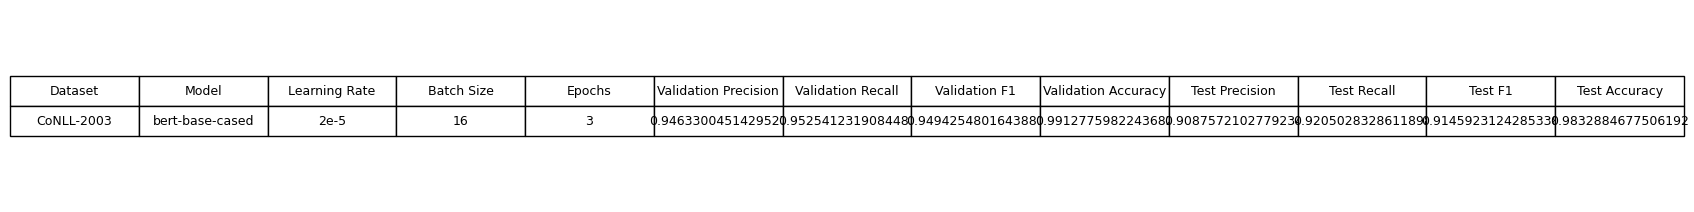

In [36]:
import matplotlib.pyplot as plt

# Create a figure to display the evaluation table
fig, ax = plt.subplots(figsize=(18, 2.5))
ax.axis('off')

# Add the table to the figure
table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    loc='center',
    cellLoc='center'
)

# Adjust table appearance
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# Save the table as a PDF file
plt.savefig("BERT_Evaluation_Table.jpg", bbox_inches='tight')
plt.show()

## Sample Named Entity Predictions

In [37]:
# Predict NER labels for one tokenized sample from the dataset
def predict_dataset_sample(sample):
    tokens = sample["tokens"]
    true_label_ids = sample["ner_tags"]

    # Tokenize using split words
    inputs = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True
    )

    # Move tensors to the same device as the model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Run model in evaluation mode
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    # Get predicted label IDs
    predictions = torch.argmax(outputs.logits, dim=2)[0].cpu().numpy()

    # Map predictions back to original words
    word_ids = tokenizer(
        tokens,
        is_split_into_words=True,
        truncation=True
    ).word_ids()

    pred_labels = []
    seen_words = set()

    for idx, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        if word_id not in seen_words:
            pred_labels.append(id_2_label[predictions[idx]])
            seen_words.add(word_id)

    true_labels = [labels[label_id] for label_id in true_label_ids]

    return tokens, true_labels, pred_labels

# Display predictions for a few examples from the test set
for i in range(3):
    sample = BERT_Dataset["test"][i]
    tokens, true_labels, pred_labels = predict_dataset_sample(sample)

    print(f"\nSample {i+1}")
    print("-" * 60)
    for token, true_label, pred_label in zip(tokens, true_labels, pred_labels):
        print(f"{token:15} True: {true_label:10} Pred: {pred_label}")


Sample 1
------------------------------------------------------------
SOCCER          True: O          Pred: O
-               True: O          Pred: O
JAPAN           True: B-LOC      Pred: B-PER
GET             True: O          Pred: O
LUCKY           True: O          Pred: B-PER
WIN             True: O          Pred: O
,               True: O          Pred: O
CHINA           True: B-PER      Pred: O
IN              True: O          Pred: O
SURPRISE        True: O          Pred: O
DEFEAT          True: O          Pred: O
.               True: O          Pred: O

Sample 2
------------------------------------------------------------
Nadim           True: B-PER      Pred: B-PER
Ladki           True: I-PER      Pred: I-PER

Sample 3
------------------------------------------------------------
AL-AIN          True: B-LOC      Pred: B-LOC
,               True: O          Pred: O
United          True: B-LOC      Pred: B-LOC
Arab            True: I-LOC      Pred: I-LOC
Emirates        True: